c:\Users\junco\anaconda3\envs\healthcare-env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31119 (\N{CJK UNIFIED IDEOGRAPH-798F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\junco\anaconda3\envs\healthcare-env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23713 (\N{CJK UNIFIED IDEOGRAPH-5CA1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\junco\anaconda3\envs\healthcare-env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30476 (\N{CJK UNIFIED IDEOGRAPH-770C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\junco\anaconda3\envs\healthcare-env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36947 (\N{CJK UNIFIED IDEOGRAPH-9053}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\junco\anaconda3\envs\healthcare-env\Lib\site-packages\IPython\core\pylabtoo

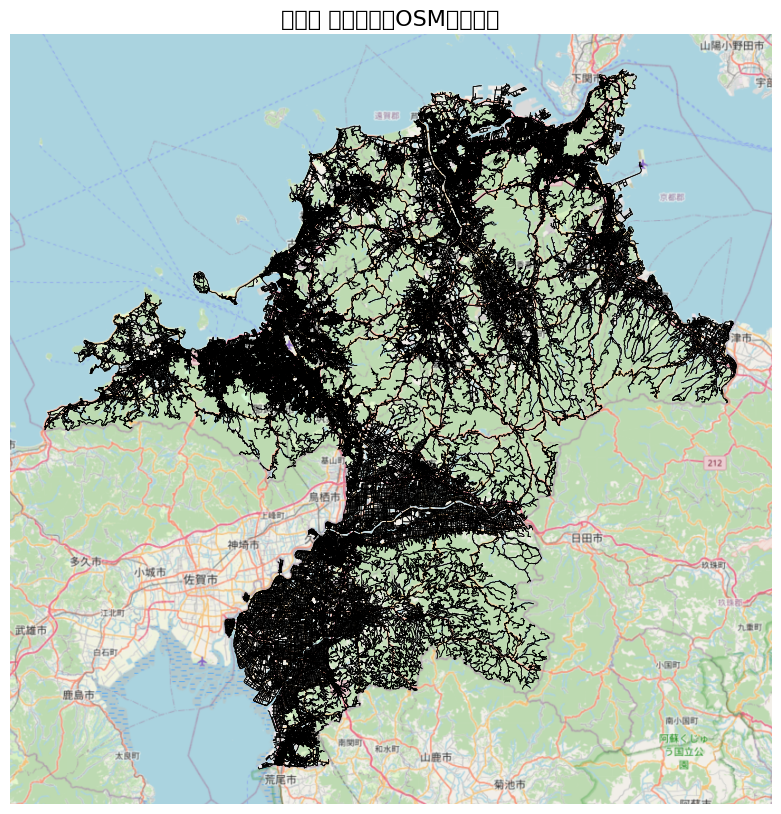

In [4]:
import osmnx as ox
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx

# 福岡県の道路データ取得
G = ox.graph_from_place("Fukuoka Prefecture, Japan", network_type='drive')
gdf = ox.graph_to_gdfs(G, nodes=False)

# 描画
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, linewidth=0.5, color='black')

# 背景地図（URLを直接指定）
ctx.add_basemap(
    ax,
    crs=gdf.crs.to_string(),
    source="https://tile.openstreetmap.org/{z}/{x}/{y}.png"
)

ax.set_title("福岡県 道路地図（OSMデータ）", fontsize=16)
ax.set_axis_off()
plt.show()



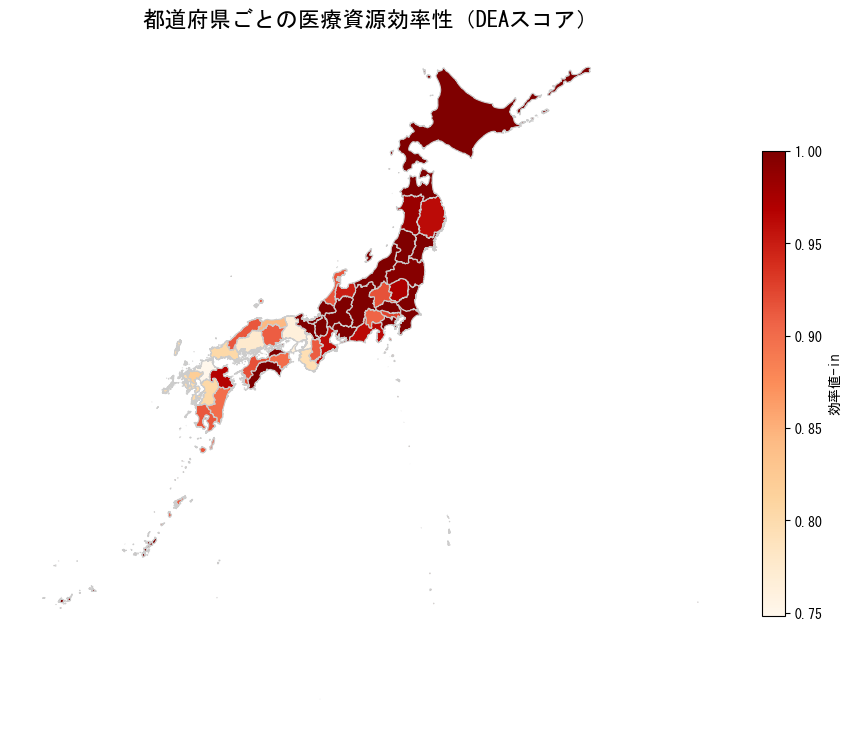

In [36]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl

# CSV 読み込み
df = pd.read_csv('dataflame_dea.csv')  # 列: 都道府県, 効率値-in

# 日本都道府県 GeoJSON を取得
url = "https://raw.githubusercontent.com/dataofjapan/land/master/japan.geojson"
gdf = gpd.read_file(url)

# CSV と GeoDataFrame を都道府県名でマージ
gdf = gdf.merge(df, left_on='nam_ja', right_on='都道府県')

# カラーマップと正規化
norm = mpl.colors.Normalize(vmin=gdf['効率値-in'].min(), vmax=gdf['効率値-in'].max())
cmap = plt.cm.OrRd

# プロット
fig, ax = plt.subplots(1, 1, figsize=(10, 12))
gdf.plot(column='効率値-in', cmap=cmap, linewidth=0.8, ax=ax, edgecolor='0.8')

# カラーバー追加
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label('効率値-in')

# 日本語フォント対応
plt.title('都道府県ごとの医療資源効率性（DEAスコア）', fontsize=16, fontname='MS Gothic')
plt.axis('off')
plt.show()



In [39]:
df[['都道府県','効率値-in']].sort_values('効率値-in',ascending=False)

,都道府県,効率値-in
0,北海道,1.000000
1,青森県,1.000000
3,宮城県,1.000000
5,山形県,1.000000
13,神奈川県,1.000000
10,埼玉県,1.000000
7,茨城県,1.000000
14,新潟県,1.000000
11,千葉県,1.000000
24,滋賀県,1.000000


<Figure size 800x600 with 0 Axes>

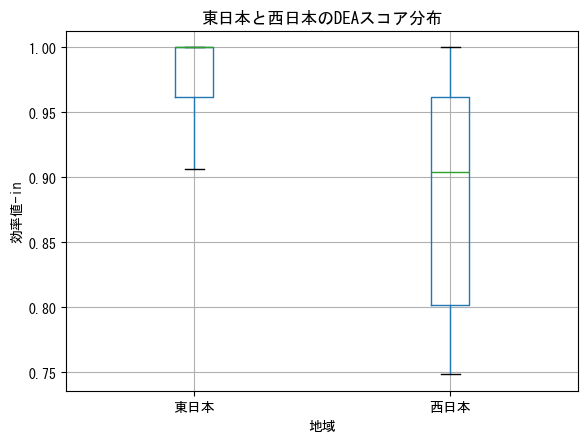

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('dataflame_dea.csv')

# 東西で分類
east = ['北海道','青森県','岩手県','宮城県','秋田県','山形県','福島県',
        '茨城県','栃木県','群馬県','埼玉県','千葉県','東京都','神奈川県','新潟県','富山県','石川県','福井県','山梨県','長野県','静岡県',
        '岐阜県','愛知県']
df['地域'] = df['都道府県'].apply(lambda x: '東日本' if x in east else '西日本')

# 箱ひげ図
plt.figure(figsize=(8,6))
df.boxplot(column='効率値-in', by='地域')
plt.title('東日本と西日本のDEAスコア分布')
plt.ylabel('効率値-in')
plt.suptitle('')
plt.show()


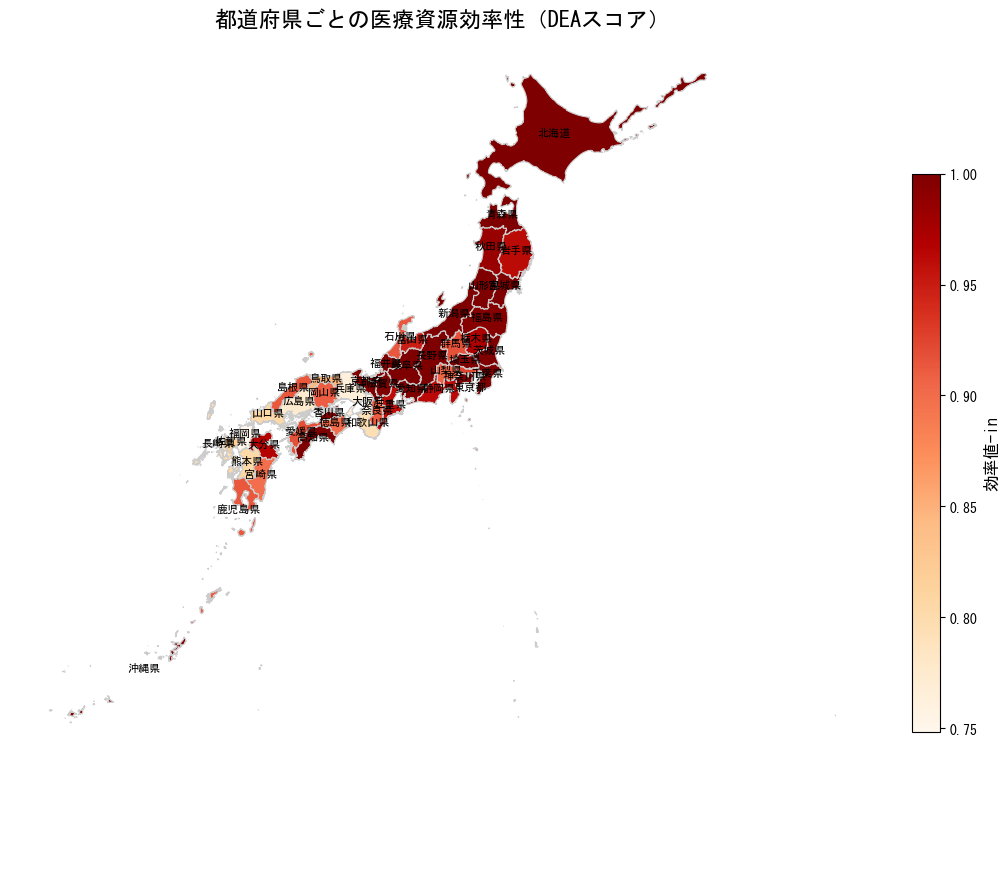

In [44]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl

# CSV読み込み
df = pd.read_csv('dataflame_dea.csv')  # 列: 都道府県, 効率値-in

# 日本都道府県 GeoJSON を取得
url = "https://raw.githubusercontent.com/dataofjapan/land/master/japan.geojson"
gdf = gpd.read_file(url)

# CSV と GeoDataFrame を都道府県名でマージ
gdf = gdf.merge(df, left_on='nam_ja', right_on='都道府県')

# カラーマップと正規化
norm = mpl.colors.Normalize(vmin=gdf['効率値-in'].min(), vmax=gdf['効率値-in'].max())
cmap = plt.cm.OrRd

# プロット
fig, ax = plt.subplots(1, 1, figsize=(12, 14))
gdf.plot(column='効率値-in', cmap=cmap, linewidth=0.8, ax=ax, edgecolor='0.8')

# カラーバー追加
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label('効率値-in', fontsize=12)

# 都道府県ラベルを追加
for idx, row in gdf.iterrows():
    plt.text(row['geometry'].centroid.x, row['geometry'].centroid.y, 
             row['都道府県'], horizontalalignment='center', fontsize=8, fontname='MS Gothic')

# 日本語フォント対応
plt.title('都道府県ごとの医療資源効率性（DEAスコア）', fontsize=16, fontname='MS Gothic')
plt.axis('off')
plt.show()
